In [5]:
import torch
import matplotlib.pyplot as plt
import utilities_tools_and_graph as graph_tools

from DIC_Net import Network, funcs, speckle_dataset, Hermite
from DIC_Net import dic_tools as dic
dic.load_interp_kernels()

path_print = 'rapport/Figures/'

In [50]:
dataset = speckle_dataset.SpeckleDataset(
    N0=1, scale=4, mode='displacement'
)
dataset.init_dataset0()

torch.manual_seed(6)
(img_ref, img_def), y, _ = dataset.__getitem__(0, case=1)

u0, v0 = 60.5, 62.5
size = 16
correlator = dic.Correlator(img_ref.to(dic.DEVICE), size, u0, v0)
uv = correlator.get_uv().to('cpu')

correlator.reset_p()
correlator.optim_correlation(img_def.to(dic.DEVICE))
uv2 = correlator.get_uv().to('cpu')

uvc = correlator.get_uvc().to('cpu')
size = 0.8*size

DATALOADER : DISPLACEMENT


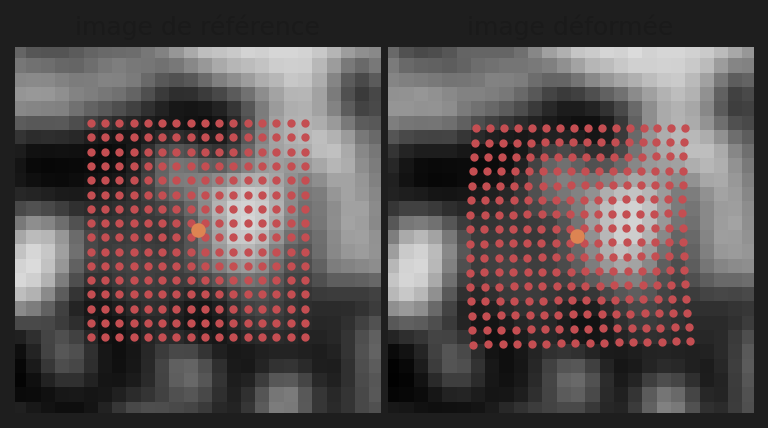

In [61]:
# fig, axs = plt.subplots(nrows=2, figsize=(2.5, 5))
fig, axs = plt.subplots(ncols=2, figsize=(5, 2.7))
ax = axs[0]
ax.set_title('image de référence', color='k')
ax.imshow(img_ref, cmap='gray')
ax.plot([], [], 'o', markersize=1.4)
ax.plot(uv[0], uv[1], 'o', color='r', markersize=3)
ax.plot([u0], [v0], 'o')
ax.set_xlim([u0-size, u0+size])
ax.set_ylim([v0+size, v0-size])
ax.axis('off')

ax = axs[1]
ax.set_title('image déformée', color='k')
ax.imshow(img_def, cmap='gray')
# ax.plot(uv[0], uv[1], 'o', markersize=1.4)
ax.plot([], [], 'o', markersize=1.4)
# ax.plot(uv[0], uv[1], 'o', markersize=1.4, label='initial')
ax.plot(uv2[0], uv2[1], 'o', color='r', markersize=3, label='estimé')
ax.plot(uvc[:1], uvc[1:], 'o')
# ax.legend(framealpha=0.8)
# ax.plot([u0], [v0], 'o')
ax.set_xlim([u0-size, u0+size])
_ = ax.set_ylim([v0+size, v0-size])
_ = ax.axis('off')

fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])
graph_tools.savefig(fig, path_print + 'dic_example')

# courbes entrainement

In [6]:
optimizer_info = {'Adam': {}}

def scheduler_func(epoch, vmin, vmax, cste, N2):
    if epoch < N2:
        return vmin + (vmax-vmin) * cste**epoch
    
    return 0.1*(vmin + (vmax-vmin) * cste**(epoch-N2))

def plot_lr(optimizer_info, scheduler_info, epochs):
    fig, ax = plt.subplots(figsize=(5,3))
    ax.semilogy(Network.get_scheduler_curve(optimizer_info, scheduler_info, epochs))
    ax.set_xlabel('epoch')
    ax.set_ylabel('learning rate')
    ax.yaxis.grid(which='minor')
    fig.tight_layout()

def plot_map_test_0(trainer, dataset):
    trainer.model.eval()

    for case in [0, 1, 2, 3, 4]:
        X, y, resample_infos = dataset.__getitem__(0, case)
        ur, vr = dataset.uvr
        ur, vr = ur.to('cuda'), vr.to('cuda')

        with torch.no_grad():
            pred = trainer.model(
                X[None], ur, vr, resample_infos[None].to('cuda')
            ).detach().clone().to('cpu')[0]
            y = y.detach().clone().to('cpu')

        # print('y:', y.shape)
        # print('pred:', pred.shape)
        # return
        k = 0
        fig, axs = plt.subplots(
            nrows=y.shape[0], ncols=2,
            figsize=(8, 3.35*y.shape[0])
            )
        fig.suptitle(f'Tailles des éléments : {Hermite.ELEMENT_SIZES[case]} pixels')
        axs[0][0].set_title('prediction')
        axs[0][1].set_title('cible')
        
        for i in range(y.shape[0]):
            vmax = max(torch.abs(pred[i]).max(), torch.abs(y[i]).max())
            im = axs[i][0].imshow(pred[i], cmap='jet', vmin=-vmax, vmax=vmax)
            fig.colorbar(im, shrink=1)
            im =axs[i][1].imshow(y[i], cmap='jet', vmin=-vmax, vmax=vmax)
            fig.colorbar(im, shrink=1)
        
        for i in range(y.shape[0]):
            for j in range(2):
                axs[i][j].axis('off')
                axs[i][j].grid('off')
        fig.tight_layout()

def plot_results(results):
    fig, ax = plt.subplots()
    ax2 = ax.twinx()
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    b_test = False

    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    for i, name in enumerate(results):
        data = funcs.load_trainer_results(name)
        label = results[name]
        print(
            f'{label} training time:',
            funcs.chrono(data['compute time'])
        )

        lrs = data['lr']
        loss_tr = data['loss']['train']
        loss_ts = data['loss']['test']

        ax.semilogy(loss_tr, color=colors[i], label=label)
        if len(loss_ts) > 0:
            ax.plot(loss_ts, '--', color=colors[i])
            b_test = True

        ax2.semilogy(lrs, ':')

    lgd = ax.legend(loc='upper right')

    hndls = []
    ln, = ax.plot([], [], 'w-', label='train')
    hndls.append(ln)
    if b_test:
        ln, =ax.plot([], [], 'w--', label='test')
        hndls.append(ln)
    ln, = ax.plot([], [], 'w:', label='learning\nrate')
    hndls.append(ln)
    lgd2 = ax.legend(
        hndls,
        [ln.get_label() for ln in hndls],
        loc='lower left',
    )

    ax.add_artist(lgd)

    # ax2.plot(lrs, color='0.5')
    ax2.set_ylabel('learning rate')
    ax2.grid(visible=False)

    # ax.grid(visible=False)
    ax.grid(visible=True)
    ax.grid(which='minor')

    ax.set_xlabel('epoch')
    ax.set_ylabel('MSE loss')
    fig.tight_layout()

DenseNet training time: 02:30:50.37
SepConv2d (4) training time: 01:28:50.78
SepConv2d (8)
Batch 1 (2) training time: 11:38:18.30
SepConv2d (8)
Batch 1 training time: 09:38:23.48
SepConv2d (8)
96 training time: 04:19:11.20


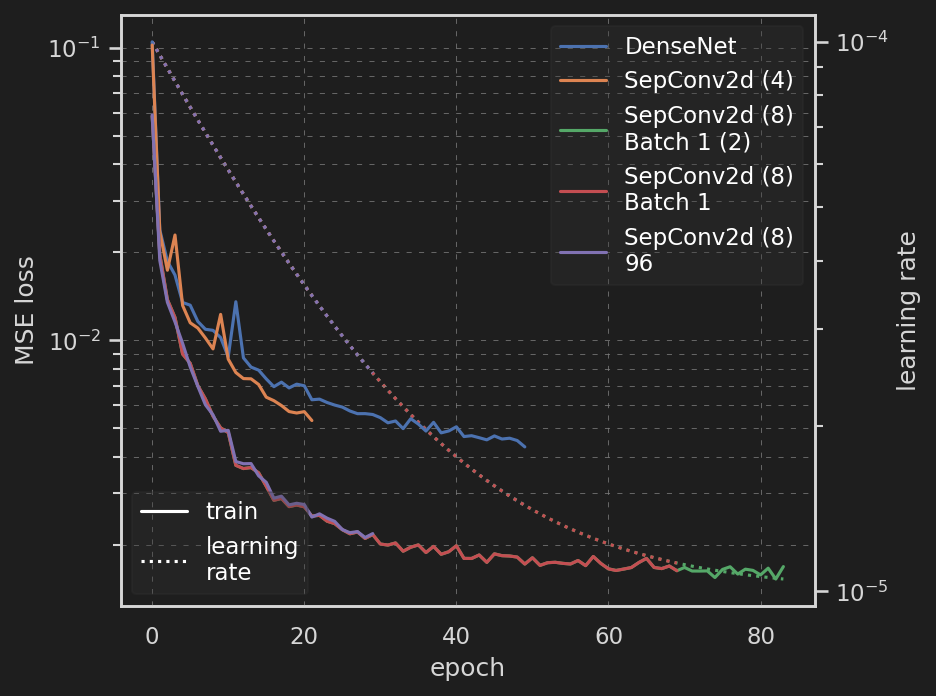

In [11]:
name = 'sepConv2d-8-Batch1-n_chan_0_96/final-disp'
results = {
    # 'Mish-GN-4-SepConv1': 'ResNet',
    # 'conv2d/final-disp': 'Conv2d',
    # 'sepConv2d/final-disp-100': 'SepConv2d',
    # 'conv2d/final-disp-00': 'final disp 0',
    # 'sepConv2d-4-Batch1/final-disp-20': 'SepConv2d (4)\nBatch 1',
    # 'sepConv2d-8-Batch1-cst_lr/final-disp-5': 'SepConv2d (8)\nBatch 1\ncst lr',
    'DenseConv': 'DenseNet',
    'sepConv2d-4/final-disp-50': 'SepConv2d (4)',
    'sepConv2d-8-Batch1/final-disp-2': 'SepConv2d (8)\nBatch 1 (2)',
    'sepConv2d-8-Batch1/final-disp': 'SepConv2d (8)\nBatch 1',
    # 'SharedSepConv2d-8-Batch1/final-disp': 'SharedSepConv2d (8)',
    # 'SharedSepConv2d-8-Batch1-groups/final-disp': 'SharedSepConv2d (8)\ngroups',
    # 'SharedSepConv2d-0-Batch1/final-disp': 'SepConv2d (0)',
    'sepConv2d-8-Batch1-n_chan_0_96/final-disp-30': 'SepConv2d (8)\n96',
}

plot_results(results)